# Ejercicio 2: Clasificación de Tumores Malignos y Benignos

## 1. Importación de Librerías

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.decomposition import PCA
from sklearn.metrics import (
    accuracy_score, f1_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)

sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams['figure.dpi'] = 110

## 2. Carga y Descripción del Dataset

In [ ]:
from google.colab import files
uploaded = files.upload()   # Subir data.csv
df = pd.read_csv('data.csv')

# Eliminar columnas no informativas
df = df.drop(columns=['id', 'Unnamed: 32'], errors='ignore')

print(f'Dimensiones del dataset: {df.shape[0]} filas x {df.shape[1]} columnas')
print(f'Valores nulos: {df.isnull().sum().sum()}')
print(f'Duplicados   : {df.duplicated().sum()}')
print()
print('Distribución de clases:')
vc = df['diagnosis'].value_counts()
for k, v in vc.items():
    print(f'  {k}: {v} muestras ({v/len(df)*100:.1f}%)')
print()
df.describe().T.round(3)

Saving data.csv to data (1).csv
Dimensiones del dataset: 569 filas x 31 columnas
Valores nulos: 0
Duplicados   : 0

Distribución de clases:
  B: 357 muestras (62.7%)
  M: 212 muestras (37.3%)



,count,mean,std,min,25%,50%,75%,max
radius_mean,569.0,14.127,3.524,6.981,11.700,13.370,15.780,28.110
texture_mean,569.0,19.290,4.301,9.710,16.170,18.840,21.800,39.280
perimeter_mean,569.0,91.969,24.299,43.790,75.170,86.240,104.100,188.500
area_mean,569.0,654.889,351.914,143.500,420.300,551.100,782.700,2501.000
smoothness_mean,569.0,0.096,0.014,0.053,0.086,0.096,0.105,0.163
compactness_mean,569.0,0.104,0.053,0.019,0.065,0.093,0.130,0.345
concavity_mean,569.0,0.089,0.080,0.000,0.030,0.062,0.131,0.427
concave points_mean,569.0,0.049,0.039,0.000,0.020,0.034,0.074,0.201
symmetry_mean,569.0,0.181,0.027,0.106,0.162,0.179,0.196,0.304
fractal_dimension_mean,569.0,0.063,0.007,0.050,0.058,0.062,0.066,0.097


## 3. Análisis Exploratorio de Datos

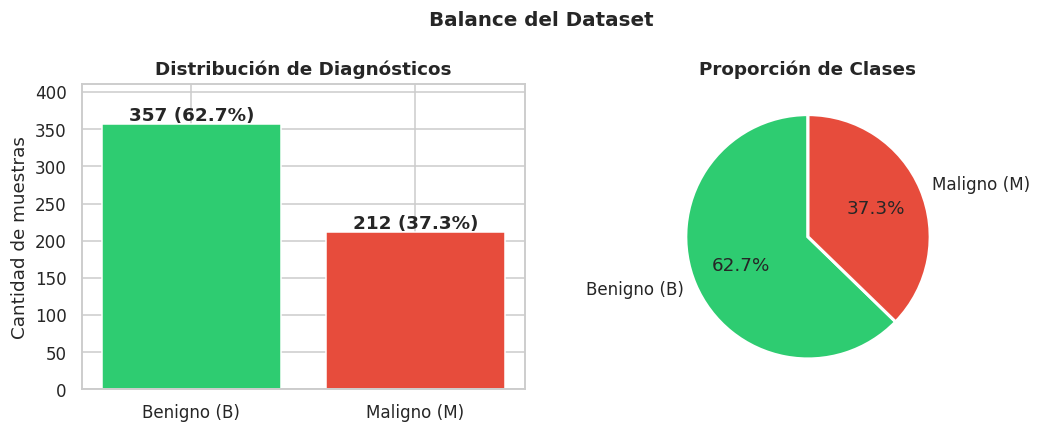

In [ ]:
# 3.1 Balance de clases
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
vc = df['diagnosis'].value_counts()
colores = ['#2ecc71', '#e74c3c']

axes[0].bar(['Benigno (B)', 'Maligno (M)'], vc.values, color=colores, edgecolor='white')
for i, v in enumerate(vc.values):
    axes[0].text(i, v + 4, f'{v} ({v/len(df)*100:.1f}%)', ha='center', fontweight='bold')
axes[0].set_title('Distribución de Diagnósticos', fontweight='bold')
axes[0].set_ylabel('Cantidad de muestras')
axes[0].set_ylim(0, max(vc.values) * 1.15)

axes[1].pie(vc.values, labels=['Benigno (B)', 'Maligno (M)'],
            autopct='%1.1f%%', colors=colores, startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Proporción de Clases', fontweight='bold')

plt.suptitle('Balance del Dataset', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

**Observación:** El dataset presenta un leve desbalance: 62.7% de muestras benignas frente a 37.3% malignas. Este desbalance no es crítico, pero se tendrá en cuenta al interpretar las métricas, priorizando el F1-Score sobre el Accuracy.

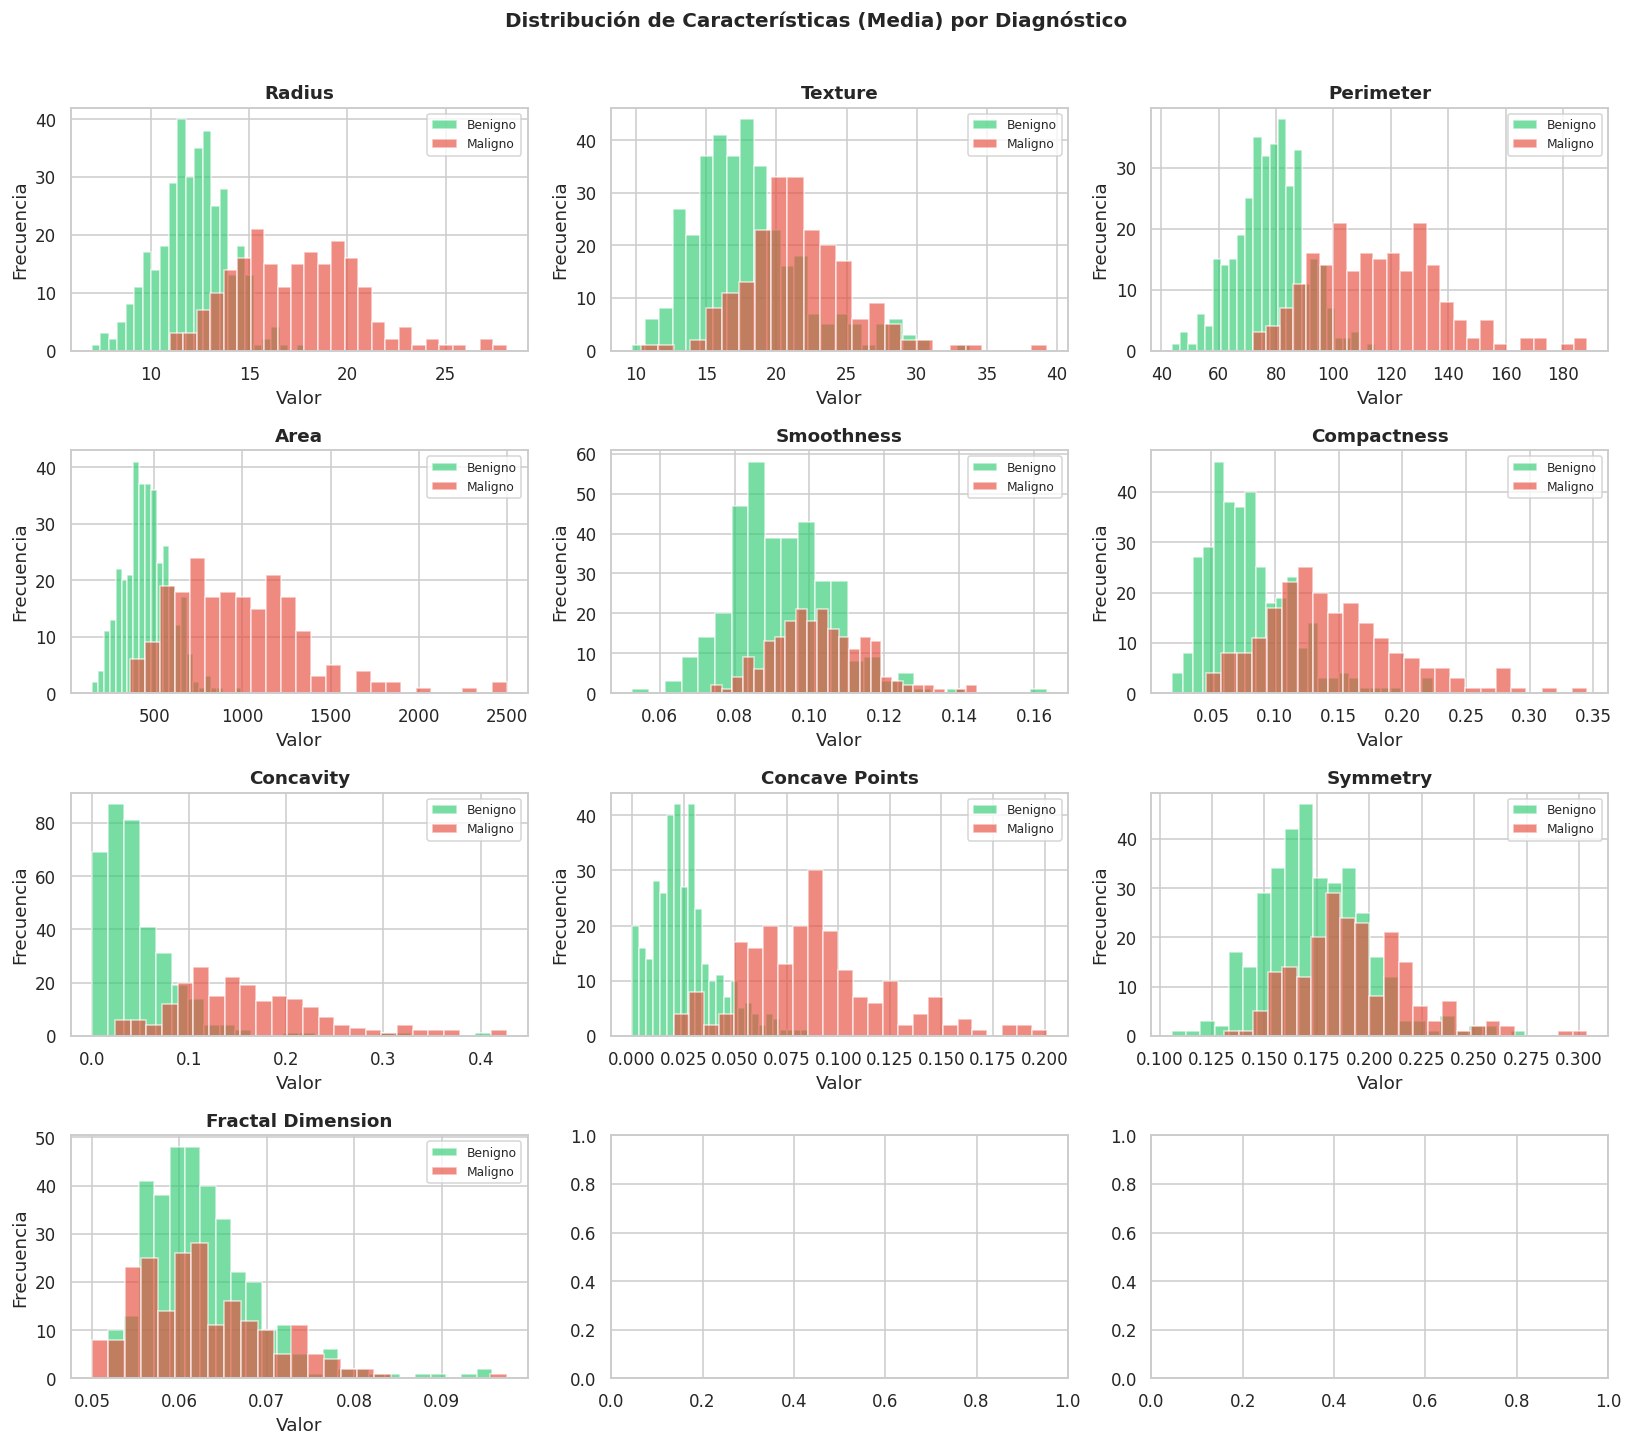

In [ ]:
# 3.2 Distribuciones por diagnóstico (histogramas)
mean_features = [c for c in df.columns if '_mean' in c]

fig, axes = plt.subplots(4, 3, figsize=(15, 13))
axes = axes.flatten()

for i, feat in enumerate(mean_features):
    for diag, color, label in zip(['B', 'M'], ['#2ecc71', '#e74c3c'], ['Benigno', 'Maligno']):
        axes[i].hist(df[df['diagnosis'] == diag][feat],
                     bins=25, alpha=0.65, color=color, label=label, edgecolor='white')
    axes[i].set_title(feat.replace('_mean', '').replace('_', ' ').title(), fontweight='bold')
    axes[i].set_xlabel('Valor')
    axes[i].set_ylabel('Frecuencia')
    axes[i].legend(fontsize=8)

plt.suptitle('Distribución de Características (Media) por Diagnóstico',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

**Observación:** Variables como radius_mean, perimeter_mean, area_mean y concave points_mean muestran separaciones notables entre clases, lo que sugiere alto poder discriminativo. En contraste, symmetry_mean y fractal_dimension_mean presentan distribuciones más superpuestas.